# 03. Abituriyentlar ma'lumotlarini tushunish (Data Understanding)

Manba: `data/processed/real_abts.csv` — `01`-notebookda tayyorlangan, har bir qator bitta abituriyent va uning imtihon fanlari juftligi.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/processed/real_abts.csv')
df.head()

,ismi,ID,toplagan_bali,1-fan,2-fan
0,URAKBAYEV N. M.,6042695,189.0,Matematika,Fizika
1,NAZEROV I. A.,6045467,189.0,Matematika,Fizika
2,TENGELOV X. I.,6872807,189.0,Matematika,Fizika
3,JANABAYEV S. O.,6259423,186.7,Matematika,Fizika
4,ERDOSHEVA X. T.,6980903,185.7,Matematika,Fizika


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 1. Umumiy tuzilma

Qatorlar soni, ustunlar, ma'lumot turlari va xotira hajmi.

In [4]:
print(f"Qatorlar: {df.shape[0]:,}  |  Ustunlar: {df.shape[1]}")
df.info(memory_usage='deep')

Qatorlar: 344,701  |  Ustunlar: 5
<class 'pandas.DataFrame'>
RangeIndex: 344701 entries, 0 to 344700
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ismi           344701 non-null  str    
 1   ID             344701 non-null  int64  
 2   toplagan_bali  344701 non-null  float64
 3   1-fan          344701 non-null  str    
 4   2-fan          344701 non-null  str    
dtypes: float64(1), int64(1), str(3)
memory usage: 68.8 MB


In [5]:
# Ustunlar tavsifi
pd.DataFrame({
    'tur': df.dtypes.astype(str),
    'noyob_qiymatlar': df.nunique(),
    'misol': df.iloc[0],
})

,tur,noyob_qiymatlar,misol
ismi,str,266256,URAKBAYEV N. M.
ID,int64,344701,6042695
toplagan_bali,float64,1403,189.0
1-fan,str,21,Matematika
2-fan,str,11,Fizika


| Ustun | Ma'nosi |
|---|---|
| `ismi` | Abituriyentning familiyasi va initsiallari |
| `ID` | Abituriyentning noyob raqami |
| `toplagan_bali` | Test sinovida to'plagan umumiy ball |
| `1-fan` | Birinchi mutaxassislik fani |
| `2-fan` | Ikkinchi mutaxassislik fani |

## 2. Ma'lumotlar sifati: bo'sh qiymatlar va takrorlar

In [6]:
pd.DataFrame({
    'bosh_soni': df.isna().sum(),
    'bosh_foizi': (df.isna().mean() * 100).round(2),
})

,bosh_soni,bosh_foizi
ismi,0,0.0
ID,0,0.0
toplagan_bali,0,0.0
1-fan,0,0.0
2-fan,0,0.0


In [7]:
print('To\'liq takrorlangan qatorlar:', df.duplicated().sum())
print('Takrorlangan ID lar:        ', df['ID'].duplicated().sum())
print('ID oralig\'i:', df['ID'].min(), '-', df['ID'].max())

To'liq takrorlangan qatorlar: 0
Takrorlangan ID lar:         0
ID oralig'i: 1000142 - 7549802


## 3. Maqsadli o'zgaruvchi: `toplagan_bali`

In [8]:
df['toplagan_bali'].describe().round(2)

count    344701.00
mean        110.69
std          42.01
min          56.70
25%          68.80
50%         105.40
75%         148.00
max         217.40
Name: toplagan_bali, dtype: float64

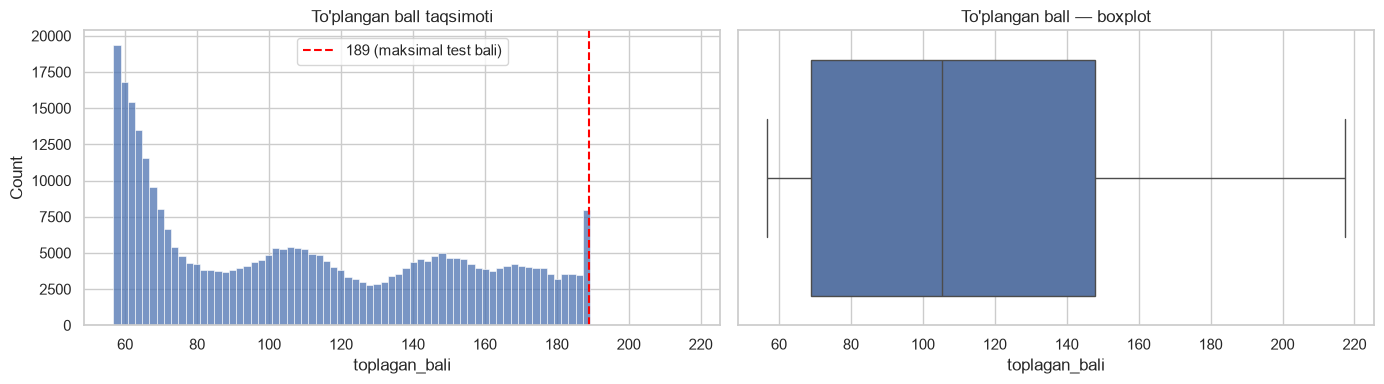

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['toplagan_bali'], bins=80, ax=axes[0])
axes[0].axvline(189, color='red', ls='--', label='189 (maksimal test bali)')
axes[0].set_title('To\'plangan ball taqsimoti')
axes[0].legend()
sns.boxplot(x=df['toplagan_bali'], ax=axes[1])
axes[1].set_title('To\'plangan ball — boxplot')
plt.tight_layout()
plt.show()

In [10]:
# Eng ko'p uchraydigan ball qiymatlari
df['toplagan_bali'].value_counts().head(10)

toplagan_bali
189.0    5797
56.7     1927
57.8     1918
56.8     1836
58.9     1777
57.9     1757
58.8     1713
59.9     1673
57.7     1593
61.0     1592
Name: count, dtype: int64

Test bo'yicha maksimal ball **189** (majburiy fanlar 3×10×1.1 = 33, 1-fan 30×3.1 = 93, 2-fan 30×2.1 = 63). Undan yuqori ballar va eng quyi chegara quyida alohida ko'riladi.

In [11]:
yuqori = df[df['toplagan_bali'] > 189]
print(f"189 dan yuqori ball: {len(yuqori)} ta qator ({len(yuqori) / len(df):.3%})")
yuqori.groupby(['1-fan', '2-fan'])['toplagan_bali'].agg(['size', 'min', 'max'])

189 dan yuqori ball: 111 ta qator (0.032%)


size    min    max
1-fan        2-fan                                    
Chet tili    Ona tili va adabiyoti     1  195.6  195.6
Fizika       Matematika                1  189.4  189.4
Fransuz tili Ona tili va adabiyoti     1  213.6  213.6
Ingliz tili  Ona tili va adabiyoti     2  189.1  196.8
Matematika   Chet tili                24  189.5  217.4
             Fizika                   35  189.1  206.3
Tarix        Chet tili                46  189.2  217.4
             Ona tili va adabiyoti     1  193.3  193.3

In [12]:
print('189 ball olganlar:', (df['toplagan_bali'] == 189).sum())
print('60 dan past ball: ', (df['toplagan_bali'] < 60).sum())
print('Eng past ball:    ', df['toplagan_bali'].min())

189 ball olganlar: 5797
60 dan past ball:  31092
Eng past ball:     56.7


## 4. Fanlar: `1-fan` va `2-fan`

In [13]:
for col in ['1-fan', '2-fan']:
    print(f"--- {col}: {df[col].nunique()} ta noyob qiymat ---")
    print(df[col].value_counts().to_string(), end='\n\n')

--- 1-fan: 21 ta noyob qiymat ---
1-fan
Matematika                      104499
Biologiya                        77697
Tarix                            30213
Ingliz tili                      25345
Oʻzbek tili va adabiyoti         24449
Huquqshunoslik fanlari           16037
Kimyo                            13710
Ona tili va adabiyoti            13653
Kasbiy (ijodiy imtihon)          11224
Fizika                            9184
Rus tili va adabiyoti             6208
Chet tili                         4602
Nemis tili                        1856
Rus tili                          1537
Geografiya                        1432
Fransuz tili                      1330
Qoraqalpoq tili va adabiyoti       754
Kasbiy (ijodiy) imtihon            648
Tojik tili va adabiyoti            162
Qozoq tili va adabiyoti            155
Turkman tili va adabiyoti            6

--- 2-fan: 11 ta noyob qiymat ---
2-fan
Chet tili                   119348
Ona tili va adabiyoti        74563
Kimyo                        4

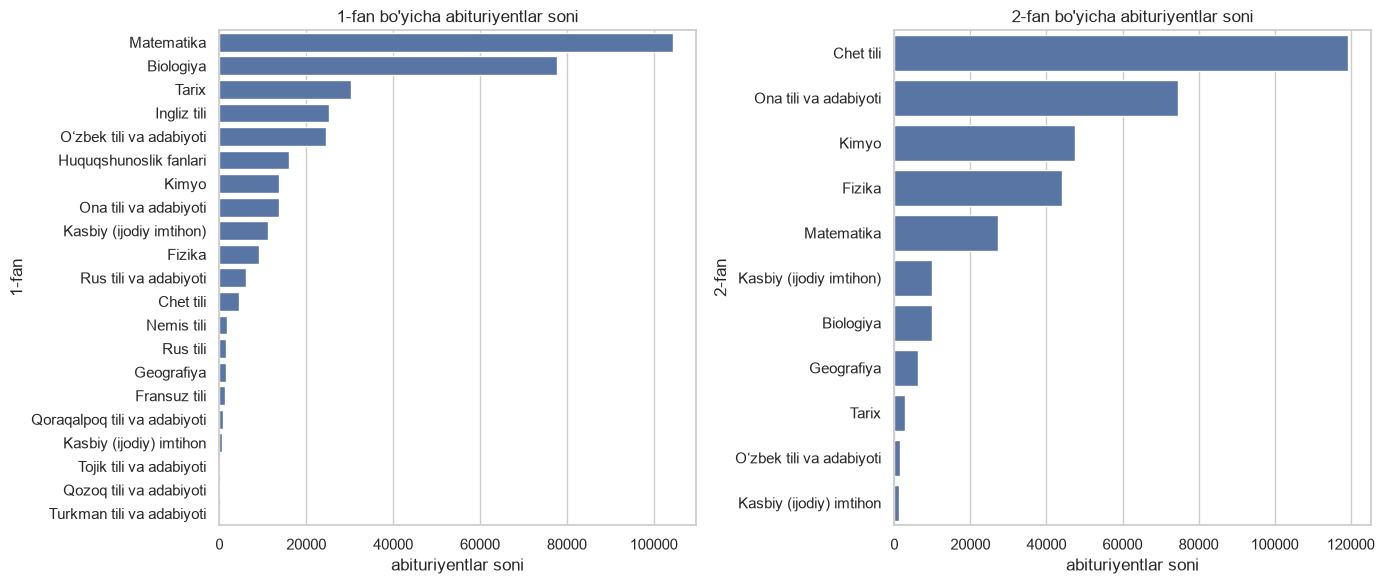

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col in zip(axes, ['1-fan', '2-fan']):
    vc = df[col].value_counts()
    sns.barplot(x=vc.values, y=vc.index, ax=ax)
    ax.set_title(f'{col} bo\'yicha abituriyentlar soni')
    ax.set_xlabel('abituriyentlar soni')
plt.tight_layout()
plt.show()

### Fan nomlaridagi nomuvofiqliklar

Bir xil fan turli yozilishda kelishi mumkin. Nomlarni kichik harf va faqat harflarga keltirib, to'qnashuvlarni qidiramiz.

In [15]:
fanlar = pd.Series(sorted(set(df['1-fan']) | set(df['2-fan'])))
kalit = fanlar.str.lower().str.replace(r'[^a-zʻ]', '', regex=True)
fanlar.groupby(kalit).agg(list)[lambda s: s.str.len() > 1]

kasbiyijodiyimtihon    [Kasbiy (ijodiy imtihon), Kasbiy (ijodiy) imti...
dtype: object

In [16]:
# Ikkala fan bir xil bo'lgan qatorlar
bir_xil = df[df['1-fan'] == df['2-fan']]
print('1-fan == 2-fan:', len(bir_xil))
bir_xil['1-fan'].value_counts()

1-fan == 2-fan: 10649


1-fan
Kasbiy (ijodiy imtihon)    10001
Kasbiy (ijodiy) imtihon      648
Name: count, dtype: int64

## 5. Fanlar juftligi va ball

In [17]:
juftlik = (df.groupby(['1-fan', '2-fan'])['toplagan_bali']
             .agg(soni='size', ortacha='mean', mediana='median', min='min', max='max')
             .round(1)
             .sort_values('soni', ascending=False))
print('Noyob juftliklar soni:', len(juftlik))
juftlik

Noyob juftliklar soni: 39


,,soni,ortacha,mediana,min,max
1-fan,2-fan,,,,,
Matematika,Chet tili,57532,109.5,102.1,56.7,217.4
Biologiya,Kimyo,47518,112.2,104.2,56.7,189.0
Matematika,Fizika,44177,92.4,71.5,56.7,206.3
Biologiya,Ona tili va adabiyoti,30179,78.5,68.7,56.7,185.0
Ingliz tili,Ona tili va adabiyoti,25345,161.2,172.1,82.7,196.8
Oʻzbek tili va adabiyoti,Chet tili,24449,133.3,142.4,56.7,189.0
Huquqshunoslik fanlari,Chet tili,16037,113.6,113.2,56.7,189.0
Tarix,Chet tili,14923,131.8,140.3,56.7,217.4
Ona tili va adabiyoti,Matematika,13497,104.5,107.7,56.7,189.0


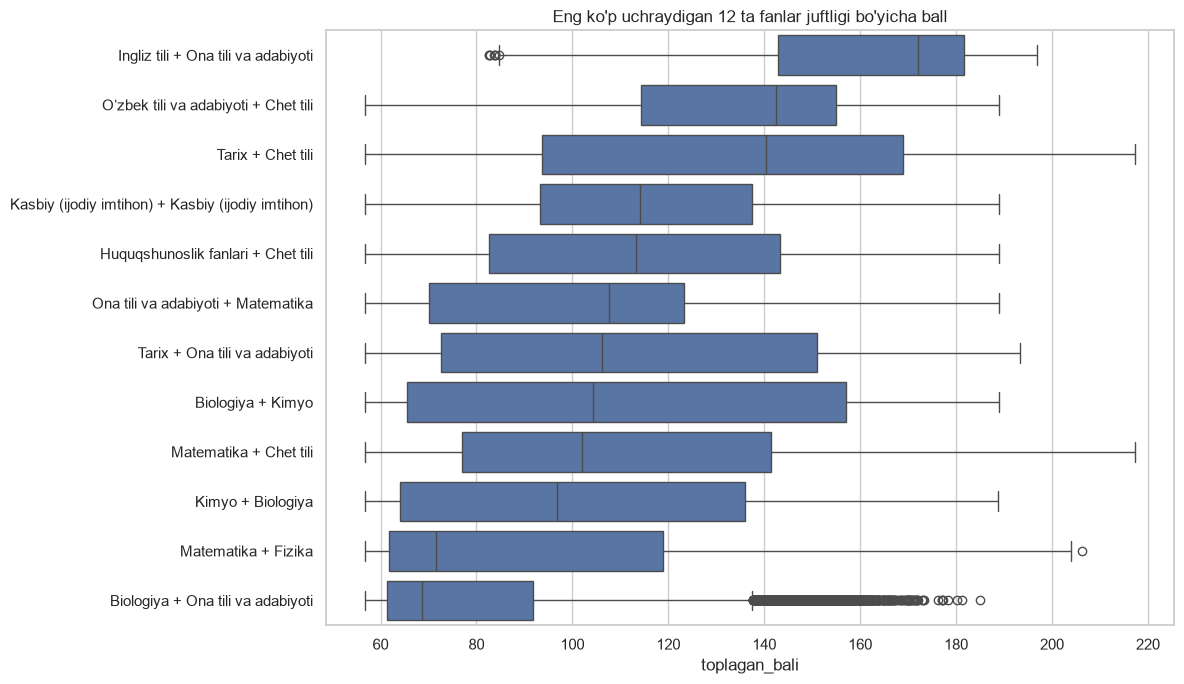

In [18]:
top = juftlik.head(12).index
sub = df.set_index(['1-fan', '2-fan']).loc[top].reset_index()
sub['juftlik'] = sub['1-fan'] + ' + ' + sub['2-fan']
tartib = sub.groupby('juftlik')['toplagan_bali'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 7))
sns.boxplot(data=sub, y='juftlik', x='toplagan_bali', order=tartib)
plt.title('Eng ko\'p uchraydigan 12 ta fanlar juftligi bo\'yicha ball')
plt.xlabel('toplagan_bali')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 6. `ismi` ustuni

In [19]:
ism = df['ismi']
print(ism.str.len().describe().round(1), end='\n\n')
print('Raqam bor:          ', ism.str.contains(r'\d').sum())
print('Kichik harf bor:    ', ism.str.contains(r'[a-z]').sum())
print('Kirill harfi bor:   ', ism.str.contains(r'[А-Яа-яЁёҚқЎўҒғҲҳ]').sum())
print('Noyob ismlar:       ', ism.nunique())

# Kutilgan format: FAMILIYA I. O. (3 ta so'z)
sozlar = ism.str.split().str.len()
print('\nSo\'zlar soni bo\'yicha:')
print(sozlar.value_counts().to_string())
ism[sozlar != 3].tolist()

count    344701.0
mean         15.9
std           2.0
min           8.0
25%          14.0
50%          16.0
75%          17.0
max          28.0
Name: ismi, dtype: float64

Raqam bor:           0
Kichik harf bor:     0


Kirill harfi bor:    4
Noyob ismlar:        266256



So'zlar soni bo'yicha:
ismi
3    344684
4        14
5         3


['AZIRBAY AQLÍǴÍ R. M.',
 'ABDUL BASIT R. X.',
 'ABDULLO - LATIBJONOVA S. SH.',
 'MAXAMADJON O‘G‘LI A. X.',
 'KOSIMJAN UULU R. X.',
 'MIR XAYDAROVA SH. F.',
 'MOXAMMAD KUL M. A.',
 'RUSTAM-VALI XAMIDIY M. O‘.',
 'DOS SANTOS Y. V.',
 'ABDUL AXAD S. R.',
 'TILYA - BALDIYEVA D. F.',
 'SOLIX NAZAROVA S. S.',
 'AL - ORIFXO‘JA D. S.',
 'MUXAMMAD XASAN I. V.',
 'MIRZA- AXMEDOV M. M.',
 'XADJI -AXUNOV A. T.',
 'XODJA- AXMEDOV U. U.']

In [20]:
# Kirill harfli ismlar
df[df['ismi'].str.contains(r'[А-Яа-яЁё]')]

,ismi,ID,toplagan_bali,1-fan,2-fan
216590,БАХТИЁРОВА М. Б.,6756722,63.3,Matematika,Fizika
267378,ШОВҚИЕВ И. С.,6307662,91.5,Matematika,Chet tili
299754,ҚУРБОНОВ А. Ж.,6308241,90.6,Matematika,Chet tili
338514,ЮЛДАШЕВА Р. Т.,6296161,111.6,Matematika,Chet tili


## 7. Xulosa

**Tuzilma.** 344 701 qator, 5 ustun. Har bir qator bitta abituriyent: `ID` to'liq noyob, to'liq takrorlangan qatorlar yo'q, bo'sh qiymatlar yo'q. Ma'lumotda OTM, yo'nalish, ta'lim tili va shakli **yo'q** — faqat ball va fanlar juftligi bor.

**`toplagan_bali`.**
- Oraliq 56.7–217.4, o'rtacha 110.7, mediana 105.4. Taqsimot o'ngga qiyshiq: pastki qismda (56–70 ball) katta to'planish bor, ~9% abituriyentning bali 60 dan past.
- 56.7 dan past ball yo'q — bu ma'lumot faqat qabul qilinganlar (yoki chegaradan o'tganlar) ekanini ko'rsatadi, ya'ni tanlanma **qirqilgan** (truncated).
- 5 797 abituriyent aynan 189 (maksimal test bali) olgan — taqsimot yuqorida ham chegaralangan.
- 111 qatorda ball 189 dan yuqori (217.4 gacha). Ular deyarli faqat `Matematika`/`Tarix` + `Chet tili`/`Fizika` juftliklarida — ehtimol sertifikat yoki imtiyoz uchun qo'shimcha ball. Xato emas, lekin modelda alohida hisobga olish kerak.

**Fanlar.**
- `1-fan` da 21 ta, `2-fan` da 11 ta qiymat, 39 ta noyob juftlik. Eng ko'plari: Matematika + Chet tili (57.5k), Biologiya + Kimyo (47.5k), Matematika + Fizika (44.2k).
- **Nomuvofiqlik:** `Kasbiy (ijodiy imtihon)` va `Kasbiy (ijodiy) imtihon` — bitta fan, ikki xil yozilgan. Birlashtirish kerak.
- 10 649 qatorda `1-fan == 2-fan` — bularning hammasi Kasbiy (ijodiy) imtihon, ya'ni xato emas.
- `Chet tili` va `Ingliz tili`/`Nemis tili`/`Fransuz tili`, `Ona tili va adabiyoti` va `Oʻzbek tili va adabiyoti` alohida qiymatlar sifatida kelgan — bu Fanlar majmuasi faylidagi nomlash farqi; ma'nosi yaqin, ularni guruhlash-guruhlamaslikni keyin hal qilish kerak.
- Juftliklar orasida ballar keskin farq qiladi (masalan, Ingliz tili + Ona tili o'rtacha 161, Biologiya + Ona tili 78) — fanlar juftligi ballni tushuntiruvchi kuchli belgi.

**`ismi`.** Shaxsiy ma'lumot, modellashtirish uchun kerak emas. Format asosan `FAMILIYA I. O.`; 17 ta ism 4–5 so'zdan iborat, 4 tasi kirillda yozilgan. Tahlilda bu ustunni tashlab yuborish mumkin.

### Keyingi qadam (Data Preparation)
1. `Kasbiy (ijodiy) imtihon` → `Kasbiy (ijodiy imtihon)` ga birlashtirish.
2. `ismi` ustunini olib tashlash.
3. 189 dan yuqori ballar uchun belgi (flag) qo'shish yoki ularni 189 bilan cheklash.
4. **Data leakage'dan saqlanish:** `abiturents.csv` / `abt_unique.csv` dagi OTM, yo'nalish, til va shakl ustunlari mandat chiqqandan keyin yig'ilgan — ular abituriyent qayerga kirganini ko'rsatadi. Hozirgi qabul tartibida abituriyent avval ballini bilib, keyin yo'nalish tanlaydi, shuning uchun bashorat paytida bu ma'lumotlar bo'lmaydi. Ularni belgi (feature) sifatida qo'shmaymiz.